# 🐔 Fase 2 · La búsqueda de días "sospechosos" (modelado no supervisado)

> **La historia.** Cada día, en cada caseta, la operación deja un rastro: cuánto alimento consumió, cuántas aves murieron, cuánto produjo. Queremos encontrar los días **raros** —los que merecen una segunda mirada— pero **nadie nos dio una lista de "respuestas correctas"**: no existen etiquetas de "esto sí fue una anomalía real". Somos detectives **sin hoja de respuestas**.

Este laboratorio es esa investigación. **No reemplaza** al pipeline de Fase 1: **lee sus resultados** (`data/processed/10_features_y_scores_diarios.csv`) y experimenta encima, sin tocar datos productivos ni guardar información sensible.

**Regla de oro de la Fase 2:** como no hay verdad de campo, el objetivo **no** es entrenar un clasificador final, sino **comparar enfoques para priorizar** qué días revisa un experto humano.

## 🎯 Las preguntas que responderemos

A lo largo del notebook iremos contestando, en orden:

1. **¿Están sanos los datos?** (calidad, nulos, rangos)
2. **¿Con qué variables describimos un día?** (y cuáles NO usar, para no hacer trampa)
3. **¿Todos los días son comparables?** (no: arranque ≠ pico ≠ fin de ciclo)
4. **¿Cómo evaluamos sin etiquetas y sin hacernos trampa con el tiempo?**
5. **¿Reproduce este laboratorio el modelo que ya corre en producción?**
6. **¿Hay algo mejor que Isolation Forest?** (lo comparamos con LOF y One-Class SVM)
7. **¿El modelo es estable**, o cambia de opinión con cada semilla/parámetro?
8. **¿En qué días coinciden varios modelos?** (consenso = más confianza)
9. **¿Detecta anomalías "plantadas" a propósito?** (nuestro examen sintético)
10. **¿Qué le entregamos al experto** para que valide?

El destino final: una **recomendación** de modelo candidato con criterios claros para promoverlo… o para descartarlo con argumentos.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.ensemble import IsolationForest
from sklearn.impute import SimpleImputer
from sklearn.metrics import pairwise_distances
from sklearn.neighbors import LocalOutlierFactor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.svm import OneClassSVM

ROOT = Path.cwd().resolve()
FEATURES_PATH = ROOT / "data" / "processed" / "10_features_y_scores_diarios.csv"
ANOMALIES_PATH = ROOT / "data" / "processed" / "11_anomalias_consumo.csv"
OUTPUT_DIR = ROOT / "reports" / "fase_2_experimentos"

RANDOM_SEEDS = [7, 13, 29, 42, 101]
CONTAMINATIONS = [0.01, 0.02, 0.035, 0.05, 0.08]
TOP_N = 50

## 1 · Cargar el rastro de la operación

Partimos de la salida de Fase 1. Estos archivos viven **solo en local** (los ignora Git por seguridad). La celda busca el CSV en `data/processed/`; si ejecutas el notebook desde la carpeta `notebooks/`, también lo busca un nivel arriba.

> Si falla con *FileNotFoundError*, primero genera los datos:
> `python -m granjas_anomalias.cli run --config config/project.yml`

**Qué cargamos:** una fila por **día · ciclo · caseta**, con consumo, producción, mortalidad, edad, fase y las features ya calculadas por el pipeline. Esa es nuestra "escena del crimen".

In [2]:
if not FEATURES_PATH.exists():
    alt_path = ROOT.parent / "data" / "processed" / "10_features_y_scores_diarios.csv"
    if alt_path.exists():
        FEATURES_PATH = alt_path
    else:
        raise FileNotFoundError(
            f"No existe {FEATURES_PATH} ni {alt_path}. Ejecute primero: "
            "python -m granjas_anomalias.cli run --config config/project.yml"
        )

features = pd.read_csv(FEATURES_PATH, parse_dates=["fecha"])
features.shape

(1965, 143)

## 2 · ¿Están sanos los datos? (primero, la higiene)

Antes de modelar miramos la materia prima. Un modelo no supervisado es **crédulo**: si una columna está medio vacía o tiene rangos imposibles, "aprenderá" ese ruido y lo confundirá con anomalías.

**Cómo leer la tabla:**
- `missing_pct` alto → variable poco confiable. *(Ojo: las features móviles tienen nulos al inicio de cada ciclo; eso es normal y esperado.)*
- `n_unique` muy bajo (0–1) → variable sin información, candidata a descartar.
- `dtype` coherente con lo que esperamos (números donde van números).

In [3]:
quality_summary = pd.DataFrame(
    {
        "dtype": features.dtypes.astype(str),
        "missing_pct": features.isna().mean().round(4),
        "n_unique": features.nunique(dropna=True),
    }
)
quality_summary.sort_values(["missing_pct", "n_unique"], ascending=[False, True]).head(40)

,dtype,missing_pct,n_unique
ica_arranque_diario,float64,0.9969,6
motivos_reglas,object,0.2656,14
motivo_anomalia,object,0.2570,21
consumo_robust_z_28,float64,0.0835,1504
ica_estandar_calculado,float64,0.0672,220
ica_diario,float64,0.0672,1759
ica_semanal_real,float64,0.0672,1824
ica_principal,float64,0.0672,1824
brecha_ica_pct,float64,0.0672,1827
brecha_ica,float64,0.0672,1828


## 3 · ¿Con qué describimos un "día"? (y la trampa de la fuga)

Elegimos variables que describen **comportamiento**, no **identidad**: consumo por ave, brecha vs. estándar, z-score robusto, cambio diario, medias/desv. móviles, mortalidad por mil, producción vs. estándar, edad y fases activas.

**Por qué NO metemos orden, lote ni documento SAP:** son *identificadores*. El modelo podría "memorizar" que cierta orden siempre es rara y marcarla por su nombre, no por su comportamiento. Eso es **fuga de información** (*data leakage*) y produce alertas inútiles. Los conservamos aparte, solo para **trazabilidad** en la revisión final.

**Elegibilidad:** entrenamos solo con días "válidos" (aves > 0, consumo ≥ 0, al menos 7 días de ciclo). El arranque de parvada es ruido puro y contaminaría el concepto de "normal".

In [4]:
MODEL_FEATURES = [
    "consumo_g_ave_dia_real",
    "brecha_consumo_pct_dia",
    "consumo_robust_z_28",
    "cambio_consumo_pct_dia",
    "consumo_promedio_7d",
    "consumo_std_7d",
    "mortalidad_por_1000",
    "ratio_produccion_vs_estandar",
    "edad_semana",
    "fases_activas_dia",
]

missing_model_features = [column for column in MODEL_FEATURES if column not in features.columns]
if missing_model_features:
    raise ValueError(f"Faltan variables candidatas: {missing_model_features}")

eligible = (
    features["aves_disponibles"].gt(0)
    & features["consumo_real_kg_dia"].ge(0)
    & features["dias_desde_inicio"].ge(7)
)

X = features.loc[eligible, MODEL_FEATURES].replace([np.inf, -np.inf], np.nan)
X.shape

(1921, 10)

## 4 · ¿Todos los días son comparables? (spoiler: no)

Un consumo que es **normal en el pico** sería **altísimo en el arranque**. Si mezclamos todo en un solo "normal", el modelo se confunde. Aquí miramos cómo cambia el comportamiento por **ciclo, caseta, edad y fase**.

**Qué observar:** si `consumo_promedio` y `score_promedio` varían mucho entre segmentos, confirma que conviene **normalizar por contexto** (ya lo hace en parte el z-score robusto por ciclo) o incluso **modelar por segmento** más adelante.

In [5]:
segment_columns = [
    column
    for column in ["cycle_id", "caseta", "edad_semana", "fase_alimento_principal"]
    if column in features.columns
]

segment_summary = (
    features.groupby(segment_columns, dropna=False)
    .agg(
        registros=("fecha", "size"),
        consumo_promedio=("consumo_real_kg_dia", "mean"),
        score_promedio=("score_anomalia", "mean"),
        alertas=("es_anomalia", "sum"),
    )
    .reset_index()
)
segment_summary.head(20)

,cycle_id,caseta,edad_semana,fase_alimento_principal,registros,consumo_promedio,score_promedio,alertas
0,1217_1007_4130_20240707,1007,16,Fase 1,7,365.714286,1.114286,0
1,1217_1007_4130_20240707,1007,17,Fase 1,7,337.142857,5.864604,0
2,1217_1007_4130_20240707,1007,18,Fase 1,7,388.571429,13.169762,0
3,1217_1007_4130_20240707,1007,19,Fase 1,6,400.000000,11.149003,0
4,1217_1007_4130_20240707,1007,19,NaN,1,0.000000,96.475080,1
5,1217_1007_4130_20240707,1007,20,Fase 1,7,400.000000,17.699994,0
6,1217_1007_4130_20240707,1007,21,Fase 1,7,400.000000,6.334549,0
7,1217_1007_4130_20240707,1007,22,Fase 1,7,400.000000,13.643791,0
8,1217_1007_4130_20240707,1007,23,Fase 1,7,400.000000,15.894148,0
9,1217_1007_4130_20240707,1007,24,Fase 1,7,320.000000,56.456802,7


## 5 · No hacernos trampa con el tiempo

La trampa más común en series temporales: usar el **futuro** para "explicar" el pasado. Para evitarlo, **partimos por fecha**: el modelo aprende qué es "normal" con el **70% más antiguo** y lo aplica al **30% más reciente** (la ventana de revisión).

> Nada de `train_test_split` aleatorio aquí: barajar los días rompería la flecha del tiempo y daría una validación optimista y **falsa**.

**Resultado esperado:** dos bloques, `X_train` (pasado) y `X_review` (reciente), que usaremos en todo el resto del notebook.

In [6]:
ordered = features.loc[eligible].sort_values("fecha").copy()
cutoff = ordered["fecha"].quantile(0.70)
train_mask = ordered["fecha"].le(cutoff)
review_mask = ordered["fecha"].gt(cutoff)

X_train = ordered.loc[train_mask, MODEL_FEATURES].replace([np.inf, -np.inf], np.nan)
X_review = ordered.loc[review_mask, MODEL_FEATURES].replace([np.inf, -np.inf], np.nan)
(X_train.shape, X_review.shape)

((1347, 10), (574, 10))

## 6 · Reproducir el modelo que YA corre en producción

Antes de buscar algo mejor, **anclamos** el baseline de Fase 1 (`models.py`): Isolation Forest con imputación por mediana y `RobustScaler`. Si no reproducimos lo que ya existe, no podremos comparar con justicia.

> **Nota técnica (importante).** `anomaly_score_from_decision` reescala el score a 0–100 con un **min-max**. Es cómodo para leer, pero **depende del lote**: el "70" de hoy no es idéntico al "70" de mañana. Lo dejamos igual que producción **para reproducir fielmente**, pero es justo uno de los puntos que la Fase 2 propone **estabilizar** (p. ej. percentiles contra la distribución de entrenamiento).

In [7]:
def anomaly_score_from_decision(decision_values: np.ndarray) -> np.ndarray:
    decision = -decision_values
    minimum = float(np.nanmin(decision))
    maximum = float(np.nanmax(decision))
    return 100 * (decision - minimum) / max(maximum - minimum, 1e-12)


baseline_model = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", RobustScaler()),
        (
            "model",
            IsolationForest(
                n_estimators=400,
                contamination=0.035,
                random_state=42,
                n_jobs=-1,
            ),
        ),
    ]
)

baseline_model.fit(X_train)
baseline_scores = anomaly_score_from_decision(baseline_model.decision_function(X_review))
baseline_flags = baseline_model.predict(X_review) == -1
pd.Series(baseline_scores).describe()

count    574.000000
mean      23.226154
std       14.523375
min        0.000000
25%       12.088603
50%       20.183630
75%       33.458573
max      100.000000
dtype: float64

## 7 · Los contendientes

Comparamos tres filosofías distintas de "rareza":

| Modelo | Intuición | Fortaleza | Cuidado |
|---|---|---|---|
| **Isolation Forest** | "lo raro se aísla con pocos cortes" | rápido, multivariante, robusto | el min-max del score |
| **Local Outlier Factor** | "lo raro vive en una zona poco poblada" | detecta rarezas **locales** | sensible a `n_neighbors` y a la densidad |
| **One-Class SVM** | "dibuja una frontera alrededor de lo normal" | flexible (kernel RBF) | costoso y muy sensible a `nu` / escala |

La idea no es coronar uno por gusto, sino ver **cuál es estable, explicable y coincide con los demás**. Estas celdas solo **definen** los modelos; los entrenamos a continuación.

In [8]:
def fit_iforest(seed: int, contamination: float):
    model = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", RobustScaler()),
            (
                "model",
                IsolationForest(
                    n_estimators=400,
                    contamination=contamination,
                    random_state=seed,
                    n_jobs=-1,
                ),
            ),
        ]
    )
    model.fit(X_train)
    return model


def fit_lof(contamination: float):
    model = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", RobustScaler()),
            (
                "model",
                LocalOutlierFactor(
                    n_neighbors=35,
                    contamination=contamination,
                    novelty=True,
                ),
            ),
        ]
    )
    model.fit(X_train)
    return model


def fit_ocsvm(nu: float):
    model = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", RobustScaler()),
            ("model", OneClassSVM(kernel="rbf", gamma="scale", nu=nu)),
        ]
    )
    model.fit(X_train)
    return model

## 8 · ¿El modelo es firme o veleta?

Un buen detector no debería **cambiar de opinión** drásticamente al mover una perilla. Aquí barremos:
- **`contamination`** (cuántas alertas esperamos: 1% a 8%),
- **semilla aleatoria** (5 semillas distintas).

**Cómo leer la tabla:**
- Si el número de `alertas` y el `score_p95` se mantienen estables entre semillas → modelo **robusto**.
- Si saltan mucho → modelo **inestable**, arriesgado para operación.
- `contamination` **no se aprende**: es un **presupuesto de alertas** que fijamos nosotros; aquí vemos cómo infla o reduce el volumen.

In [9]:
experiment_rows = []
score_table = pd.DataFrame(index=ordered.loc[review_mask].index)

for contamination in CONTAMINATIONS:
    for seed in RANDOM_SEEDS:
        model = fit_iforest(seed=seed, contamination=contamination)
        score = anomaly_score_from_decision(model.decision_function(X_review))
        flag = model.predict(X_review) == -1
        name = f"iforest_c{contamination}_s{seed}"
        score_table[name] = score
        experiment_rows.append(
            {
                "modelo": "IsolationForest",
                "contamination": contamination,
                "seed": seed,
                "alertas": int(flag.sum()),
                "score_p95": float(np.percentile(score, 95)),
            }
        )

experiments = pd.DataFrame(experiment_rows)
experiments

,modelo,contamination,seed,alertas,score_p95
0,IsolationForest,0.010,7,2,48.666480
1,IsolationForest,0.010,13,2,52.677114
2,IsolationForest,0.010,29,5,50.262797
3,IsolationForest,0.010,42,2,49.817608
4,IsolationForest,0.010,101,2,48.416172
5,IsolationForest,0.020,7,45,48.666480
6,IsolationForest,0.020,13,43,52.677114
7,IsolationForest,0.020,29,29,50.262797
8,IsolationForest,0.020,42,29,49.817608
9,IsolationForest,0.020,101,19,48.416172


## 9 · La sabiduría del consenso

Sin etiquetas, **el acuerdo entre modelos distintos es nuestra mejor señal de confianza**: si Isolation Forest, LOF y One-Class SVM —que razonan diferente— coinciden en que un día es raro, probablemente lo sea.

**Qué observar:** la columna `acuerdo_modelos` (0 a 3). Los días con **3/3** y score alto son los **candidatos más sólidos** para revisión experta.

In [10]:
lof_model = fit_lof(contamination=0.035)
ocsvm_model = fit_ocsvm(nu=0.035)

agreement = ordered.loc[review_mask].copy()
agreement["score_iforest"] = baseline_scores
agreement["flag_iforest"] = baseline_flags
agreement["score_lof"] = anomaly_score_from_decision(lof_model.decision_function(X_review))
agreement["flag_lof"] = lof_model.predict(X_review) == -1
agreement["score_ocsvm"] = anomaly_score_from_decision(ocsvm_model.decision_function(X_review))
agreement["flag_ocsvm"] = ocsvm_model.predict(X_review) == -1
agreement["acuerdo_modelos"] = agreement[["flag_iforest", "flag_lof", "flag_ocsvm"]].sum(axis=1)

agreement[["fecha", "cycle_id", "caseta", "score_iforest", "score_lof", "score_ocsvm", "acuerdo_modelos"]].sort_values(
    ["acuerdo_modelos", "score_iforest"], ascending=False
).head(TOP_N)

,fecha,cycle_id,caseta,score_iforest,score_lof,score_ocsvm,acuerdo_modelos
1181,2025-12-15,1217_1008_4130_20240707,1008,100.000000,100.000000,100.000000,3
1819,2025-11-28,1217_1009_4131_20240707,1009,60.128581,49.867498,20.084062,3
1836,2025-12-15,1217_1009_4131_20240707,1009,99.415270,9.531211,44.238740,2
1925,2026-05-06,1217_1009_4785_20260208,1009,49.446106,49.982390,12.394448,2
1926,2026-05-07,1217_1009_4785_20260208,1009,45.440458,36.282164,8.177528,2
1956,2026-06-06,1217_1009_4785_20260208,1009,39.402232,51.749077,16.804282,2
1212,2026-03-09,1217_1008_4784_20260207,1008,58.209504,8.917571,8.066467,1
1869,2026-03-11,1217_1009_4785_20260208,1009,58.066332,24.488665,1.328669,1
1867,2026-03-09,1217_1009_4785_20260208,1009,57.890663,13.129952,7.599663,1
1226,2026-03-23,1217_1008_4784_20260207,1008,57.106146,23.431969,6.042537,1


## 10 · El examen sin respuestas: anomalías plantadas

¿Cómo medimos algo parecido a "recall" si no tenemos verdad? **Plantamos** anomalías a propósito en una copia (consumo inflado, saltos abruptos) y vemos si el modelo las **ilumina**. Es un examen cuyas respuestas escondimos nosotros mismos.

> ⚠️ Estas perturbaciones son **solo para probar sensibilidad**. Jamás se usan como datos de entrenamiento ni como "verdad" — eso sería inventar realidad.

**Qué observar:** el score de las filas perturbadas debería ser **claramente más alto** que el del día original. Si no sube, el modelo es poco sensible a ese tipo de anomalía.

In [11]:
synthetic = ordered.loc[review_mask].copy()
synthetic_features = synthetic[MODEL_FEATURES].copy()

if not synthetic_features.empty:
    perturbed = synthetic_features.copy()
    sample_index = perturbed.index[: min(10, len(perturbed))]
    perturbed.loc[sample_index, "consumo_g_ave_dia_real"] *= 1.8
    perturbed.loc[sample_index, "cambio_consumo_pct_dia"] = 0.8
    perturbed_scores = anomaly_score_from_decision(baseline_model.decision_function(perturbed))
else:
    perturbed_scores = np.array([])

pd.Series(perturbed_scores).describe()

count    574.000000
mean      23.579042
std       15.065937
min        0.000000
25%       12.088603
50%       20.214964
75%       33.587302
max      100.000000
dtype: float64

## 11 · El paquete para el experto humano

El modelo **prioriza**; el humano **decide**. Armamos un top-N con todo el contexto que un operador necesita para juzgar cada caso: fecha, ciclo, caseta, edad, fase, consumo real vs. estándar, scores de cada modelo, acuerdo y motivo.

> 🔒 **Seguridad.** Este top-N contiene datos reales: exportarlo solo a destino local y seguro; **nunca** publicarlo. Esa revisión, registrada en `reports/tables/05_plantilla_validacion_anomalias.csv`, es la que con el tiempo nos dará **etiquetas** para una posible etapa supervisada.

In [12]:
review_columns = [
    column
    for column in [
        "fecha",
        "cycle_id",
        "caseta",
        "edad_semana",
        "fase_alimento_principal",
        "consumo_real_kg_dia",
        "consumo_estandar_kg_dia",
        "score_anomalia",
        "severidad",
        "motivo_anomalia",
        "score_iforest",
        "score_lof",
        "score_ocsvm",
        "acuerdo_modelos",
    ]
    if column in agreement.columns
]

top_n_review = agreement.sort_values(
    ["acuerdo_modelos", "score_iforest"], ascending=False
).head(TOP_N)[review_columns]

top_n_review

,fecha,cycle_id,caseta,edad_semana,fase_alimento_principal,consumo_real_kg_dia,consumo_estandar_kg_dia,score_anomalia,severidad,motivo_anomalia,score_iforest,score_lof,score_ocsvm,acuerdo_modelos
1181,2025-12-15,1217_1008_4130_20240707,1008,91,NaN,0.0,68.420,98.050000,critica,desviación robusta; brecha contra política; br...,100.000000,100.000000,100.000000,3
1819,2025-11-28,1217_1009_4131_20240707,1009,88,Fase 5,470.0,511.060,18.436227,baja,patrón multivariable atípico,60.128581,49.867498,20.084062,3
1836,2025-12-15,1217_1009_4131_20240707,1009,91,NaN,0.0,508.200,97.426458,critica,desviación robusta; brecha contra política; br...,99.415270,9.531211,44.238740,2
1925,2026-05-06,1217_1009_4785_20260208,1009,28,Fase 1,480.0,529.329,16.496888,baja,patrón multivariable atípico,49.446106,49.982390,12.394448,2
1926,2026-05-07,1217_1009_4785_20260208,1009,28,Fase 1,480.0,528.580,15.033828,baja,NaN,45.440458,36.282164,8.177528,2
1956,2026-06-06,1217_1009_4785_20260208,1009,32,Fase 1,460.0,539.440,19.317494,baja,mortalidad alta,39.402232,51.749077,16.804282,2
1212,2026-03-09,1217_1008_4784_20260207,1008,20,Fase 1,390.0,444.733,27.128798,baja,cambio abrupto; patrón multivariable atípico,58.209504,8.917571,8.066467,1
1869,2026-03-11,1217_1009_4785_20260208,1009,20,Fase 1,300.0,444.110,39.337513,baja,brecha contra política; brecha crítica contra ...,58.066332,24.488665,1.328669,1
1867,2026-03-09,1217_1009_4785_20260208,1009,20,Fase 1,390.0,444.288,27.047700,baja,cambio abrupto; patrón multivariable atípico,57.890663,13.129952,7.599663,1
1226,2026-03-23,1217_1008_4784_20260207,1008,22,Fase 1,500.0,484.127,38.619645,baja,desviación robusta; patrón multivariable atípico,57.106146,23.431969,6.042537,1


## 13 · Score estable y paridad con producción (pasos 6 y 1)

Dos arreglos clave antes de comparar en serio:

- **(6) Normalización estable del score:** en lugar del min-max dependiente del lote, mapeamos la "rareza" al **percentil contra la distribución de entrenamiento**. Así, dos lotes distintos son comparables y el "70" significa lo mismo siempre.
- **(1) Paridad con producción:** reentrenamos Isolation Forest *como en `models.py`* (sobre **todos** los elegibles) y comparamos su ranking con el `score_ml` que ya trae el CSV. Una correlación de Spearman cercana a **1.0** confirma que reproducimos fielmente el modelo productivo.

In [13]:
from scipy.stats import spearmanr

# (6) Normalización ESTABLE: percentil de la "rareza" (-decision_function)
# respecto a la distribución de ENTRENAMIENTO -> reproducible entre lotes.
def stable_score(train_decision, eval_decision):
    train_anom = np.sort(-np.asarray(train_decision, dtype=float))
    eval_anom = -np.asarray(eval_decision, dtype=float)
    pct = np.searchsorted(train_anom, eval_anom, side="right") / max(len(train_anom), 1)
    return 100.0 * pct

train_decision = baseline_model.decision_function(X_train)
baseline_score_stable = stable_score(train_decision, baseline_model.decision_function(X_review))

# (1) Paridad con producción: reentrenar IF como en models.py (TODOS los elegibles).
prod_like = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler()),
    ("model", IsolationForest(n_estimators=400, contamination=0.035,
                              random_state=42, n_jobs=-1)),
])
X_all = features.loc[eligible, MODEL_FEATURES].replace([np.inf, -np.inf], np.nan)
prod_like.fit(X_all)
nb_score = anomaly_score_from_decision(prod_like.decision_function(X_all))

paridad = np.nan
if "score_ml" in features.columns:
    prod_score = features.loc[eligible, "score_ml"].to_numpy(dtype=float)
    paridad = spearmanr(nb_score, prod_score, nan_policy="omit").correlation

print(
    f"Paridad (Spearman vs score_ml de produccion): {paridad:.4f}"
    if np.isfinite(paridad)
    else "No hay columna score_ml para comparar la paridad."
)
pd.DataFrame({
    "score_minmax (lote)": pd.Series(baseline_scores).describe(),
    "score_estable (percentil train)": pd.Series(baseline_score_stable).describe(),
})

Paridad (Spearman vs score_ml de produccion): 1.0000


,score_minmax (lote),score_estable (percentil train)
count,574.000000,574.000000
mean,23.226154,72.947368
std,14.523375,17.905463
min,0.000000,26.948775
25%,12.088603,60.356347
50%,20.183630,73.645137
75%,33.458573,89.383816
max,100.000000,99.851522


## 14 · EDA del score y por segmento (paso 2)

Miramos la **forma** del score estable: un buen detector produce una distribución con la mayoría de días en valores bajos y una **cola corta** de días raros. Y revisamos si el score mediano cambia por **fase/edad**, lo que confirmaría si conviene normalizar más por contexto.

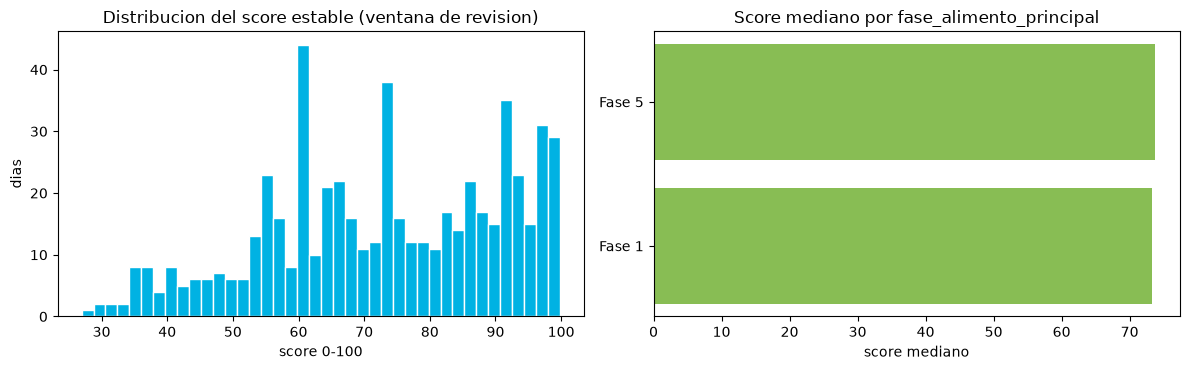

In [14]:
import matplotlib.pyplot as plt

review = ordered.loc[review_mask].copy()
review["score_estable"] = baseline_score_stable

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
axes[0].hist(baseline_score_stable, bins=40, color="#00B2E3", edgecolor="white")
axes[0].set_title("Distribucion del score estable (ventana de revision)")
axes[0].set_xlabel("score 0-100")
axes[0].set_ylabel("dias")

seg_col = next(
    (c for c in ["fase_alimento_principal", "fase", "edad_semana", "caseta"] if c in review.columns),
    None,
)
if seg_col:
    grp = review.groupby(seg_col)["score_estable"].median().sort_values()
    axes[1].barh(grp.index.astype(str), grp.values, color="#88BD54")
    axes[1].set_title(f"Score mediano por {seg_col}")
    axes[1].set_xlabel("score mediano")
else:
    axes[1].text(0.5, 0.5, "Sin columna de segmento disponible", ha="center", va="center")
    axes[1].axis("off")

plt.tight_layout()
plt.show()

## 15 · Benchmark sintético: ¿qué modelo detecta mejor? (pasos 3 y 4)

Aquí resolvemos el problema de "no tener etiquetas": **plantamos** 4 arquetipos de anomalía con **etiqueta conocida** sobre días normales y medimos qué tan bien cada modelo los separa, con **Average Precision** (área bajo la curva precisión-recall) y **recall@k**.

Arquetipos: consumo muy alto, **consumo cero con aves**, **salto abrupto** y **mortalidad elevada**.

**Cómo leer:** mayor `average_precision` = mejor detección. Es la primera métrica **comparable entre IF, LOF y One-Class SVM**.

> ⚠️ Las anomalías sintéticas son un *examen* de sensibilidad, no datos de entrenamiento ni verdad de campo.

In [15]:
from sklearn.metrics import average_precision_score

rng = np.random.default_rng(0)
medians = X_train.median()
base_clean = X_review.fillna(medians)  # base "normal" sin nulos para inyectar encima


def inject_synthetic_anomalies(base, n_per_type=60):
    def take():
        idx = rng.integers(0, len(base), n_per_type)
        return base.iloc[idx].reset_index(drop=True).copy()

    alto = take()
    alto["consumo_g_ave_dia_real"] *= 1.9
    alto["brecha_consumo_pct_dia"] = alto["brecha_consumo_pct_dia"].abs() + 0.6

    cero = take()
    cero["consumo_g_ave_dia_real"] = 0.0
    cero["consumo_robust_z_28"] = -6.0

    salto = take()
    salto["cambio_consumo_pct_dia"] = 0.9
    salto["consumo_robust_z_28"] = 5.0

    mort = take()
    mort["mortalidad_por_1000"] = mort["mortalidad_por_1000"] + 40.0

    anomalies = pd.concat([alto, cero, salto, mort], ignore_index=True)
    X_b = pd.concat([base.reset_index(drop=True), anomalies], ignore_index=True)
    y_b = np.r_[np.zeros(len(base)), np.ones(len(anomalies))]
    return X_b, y_b


X_bench, y_bench = inject_synthetic_anomalies(base_clean)
bench_models = {"IsolationForest": baseline_model, "LOF": lof_model, "OneClassSVM": ocsvm_model}

bench_rows = []
k = int(y_bench.sum())
for name, model in bench_models.items():
    raw = -model.decision_function(X_bench)  # mayor = mas anomalo
    ap = average_precision_score(y_bench, raw)
    topk = np.argsort(raw)[-k:]
    recall_topk = float(y_bench[topk].sum() / k)
    bench_rows.append({
        "modelo": name,
        "average_precision": round(float(ap), 3),
        f"recall@{k}": round(recall_topk, 3),
    })

benchmark = pd.DataFrame(bench_rows).sort_values("average_precision", ascending=False).reset_index(drop=True)
benchmark

,modelo,average_precision,recall@240
0,LOF,0.891,0.821
1,OneClassSVM,0.817,0.683
2,IsolationForest,0.710,0.679


## 16 · ¿El "normal" del pasado sigue valiendo? Deriva con PSI (paso 5)

Entrenamos con el pasado y puntuamos el presente. Pero si la operación cambió (otra dieta, genética, estación), el "normal" se mueve y el modelo empieza a fallar. El **PSI** (Population Stability Index) mide ese desplazamiento por feature.

**Regla práctica:** PSI **< 0.1** estable · **0.1–0.25** vigilar · **> 0.25** deriva fuerte (reentrenar / re-segmentar).

In [16]:
def population_stability_index(expected, actual, bins=10):
    expected = pd.Series(expected).replace([np.inf, -np.inf], np.nan).dropna()
    actual = pd.Series(actual).replace([np.inf, -np.inf], np.nan).dropna()
    if len(expected) < 20 or len(actual) < 20:
        return np.nan
    edges = np.unique(np.quantile(expected, np.linspace(0, 1, bins + 1)))
    if len(edges) < 3:
        return np.nan
    e = np.histogram(expected, bins=edges)[0] / len(expected)
    a = np.histogram(actual, bins=edges)[0] / len(actual)
    e = np.clip(e, 1e-6, None)
    a = np.clip(a, 1e-6, None)
    return float(np.sum((a - e) * np.log(a / e)))


drift = pd.DataFrame({
    "feature": MODEL_FEATURES,
    "psi": [round(population_stability_index(X_train[c], X_review[c]), 3) for c in MODEL_FEATURES],
})
drift["estado"] = pd.cut(
    drift["psi"], bins=[-0.01, 0.1, 0.25, np.inf],
    labels=["estable", "vigilar", "deriva fuerte"],
).astype("string")
drift.sort_values("psi", ascending=False).reset_index(drop=True)

,feature,psi,estado
0,edad_semana,7.177,deriva fuerte
1,brecha_consumo_pct_dia,1.088,deriva fuerte
2,consumo_std_7d,0.734,deriva fuerte
3,consumo_promedio_7d,0.608,deriva fuerte
4,consumo_g_ave_dia_real,0.547,deriva fuerte
5,consumo_robust_z_28,0.481,deriva fuerte
6,mortalidad_por_1000,0.400,deriva fuerte
7,ratio_produccion_vs_estandar,0.274,deriva fuerte
8,cambio_consumo_pct_dia,0.084,estable
9,fases_activas_dia,0.001,estable


## 17 · Explicabilidad: ¿por qué este día es raro? (paso 7)

Un score sin explicación no sirve al operador. Para cada alerta calculamos qué **features se alejan más de lo normal** (z robusto contra la distribución de entrenamiento) y mostramos las 3 dominantes. Así el experto ve *qué* disparó la alerta y no solo un número.

Esto cubre la principal debilidad del baseline, cuyo `motivo_anomalia` se apoyaba solo en las reglas.

In [17]:
# z robusto de cada feature contra la distribucion de ENTRENAMIENTO
train_median = X_train.median()
train_mad = ((X_train - train_median).abs().median() * 1.4826).replace(0, np.nan)


def dominant_features(row, k=3):
    z = ((row[MODEL_FEATURES] - train_median) / train_mad).abs().dropna()
    top = z.sort_values(ascending=False).head(k)
    return "; ".join(f"{name} (z~{val:.1f})" for name, val in top.items())


explained = ordered.loc[review_mask].copy()
explained["score_estable"] = baseline_score_stable
explained["features_dominantes"] = explained.apply(dominant_features, axis=1)

cols_expl = [
    c for c in ["fecha", "cycle_id", "caseta", "edad_semana", "score_estable", "features_dominantes"]
    if c in explained.columns
]
explained.sort_values("score_estable", ascending=False)[cols_expl].head(15).reset_index(drop=True)

,fecha,cycle_id,caseta,edad_semana,score_estable,features_dominantes
0,2025-12-15,1217_1008_4130_20240707,1008,91,99.851522,ratio_produccion_vs_estandar (z~95.9); consumo...
1,2025-12-15,1217_1009_4131_20240707,1009,91,99.851522,consumo_robust_z_28 (z~36.6); brecha_consumo_p...
2,2025-11-28,1217_1009_4131_20240707,1009,88,98.812175,ratio_produccion_vs_estandar (z~2.1); edad_sem...
3,2026-03-09,1217_1008_4784_20260207,1008,20,98.737936,ratio_produccion_vs_estandar (z~12.4); consumo...
4,2026-04-26,1217_1009_4785_20260208,1009,27,98.737936,consumo_g_ave_dia_real (z~1.4); brecha_consumo...
5,2026-03-23,1217_1008_4784_20260207,1008,22,98.737936,consumo_robust_z_28 (z~5.1); ratio_produccion_...
6,2026-03-09,1217_1009_4785_20260208,1009,20,98.737936,ratio_produccion_vs_estandar (z~12.0); consumo...
7,2026-03-11,1217_1009_4785_20260208,1009,20,98.737936,ratio_produccion_vs_estandar (z~9.9); consumo_...
8,2025-10-07,1217_1009_4131_20240707,1009,81,98.737936,consumo_robust_z_28 (z~9.6); consumo_promedio_...
9,2025-10-06,1217_1007_4130_20240707,1007,81,98.737936,brecha_consumo_pct_dia (z~2.5); consumo_g_ave_...


## 18 · Tablero comparativo y recomendación automática (paso 9)

Reunimos las señales de cada modelo —**detección sintética** (AP), **tasa de alertas** y **estabilidad** entre semillas— en una sola tabla y derivamos una **recomendación heurística**. No sustituye al experto: lo orienta.

**Criterio:** preferir el modelo con mayor AP que mantenga una **tasa de alertas operativa (~2–5%)**, sea **explicable** y **estable**. Hasta tener validación experta, **conservar la combinación con reglas** (0.65 reglas / 0.35 ML).

In [18]:
# Estabilidad de IF entre semillas (desviacion del num. de alertas) a contaminacion base
if "experiments" in globals():
    stab = experiments.loc[experiments["contamination"] == 0.035, "alertas"]
    if_stability = round(float(stab.std()), 1) if len(stab) else np.nan
else:
    if_stability = np.nan

alert_rate = {
    "IsolationForest": float((baseline_model.predict(X_review) == -1).mean()),
    "LOF": float((lof_model.predict(X_review) == -1).mean()),
    "OneClassSVM": float((ocsvm_model.predict(X_review) == -1).mean()),
}

summary = benchmark.merge(
    pd.DataFrame({
        "modelo": list(alert_rate),
        "tasa_alertas": [round(v, 3) for v in alert_rate.values()],
    }),
    on="modelo", how="left",
)
summary["estabilidad_IF_std_alertas"] = np.where(
    summary["modelo"] == "IsolationForest", if_stability, np.nan
)

operativo = summary[summary["tasa_alertas"].between(0.02, 0.06)]
candidatos = operativo if not operativo.empty else summary
best = candidatos.sort_values("average_precision", ascending=False).iloc[0]

print("=" * 64)
print("RECOMENDACION HEURISTICA (orienta; la valida el experto)")
print("=" * 64)
print(f"- Mejor deteccion sintetica: {best['modelo']} (AP = {best['average_precision']}).")
print(f"- Tasa de alertas en revision: {best['tasa_alertas']:.1%}.")
if np.isfinite(if_stability):
    print(f"- Estabilidad IF entre semillas (std de alertas): {if_stability}.")
print("- Accion: mantener la combinacion reglas+ML (0.65/0.35) y el score ESTABLE;")
print("  promover el modelo solo tras validacion experta del top-N.")
print("=" * 64)
summary

RECOMENDACION HEURISTICA (orienta; la valida el experto)
- Mejor deteccion sintetica: LOF (AP = 0.891).
- Tasa de alertas en revision: 4.9%.
- Estabilidad IF entre semillas (std de alertas): 3.4.
- Accion: mantener la combinacion reglas+ML (0.65/0.35) y el score ESTABLE;
  promover el modelo solo tras validacion experta del top-N.


,modelo,average_precision,recall@240,tasa_alertas,estabilidad_IF_std_alertas
0,LOF,0.891,0.821,0.049,NaN
1,OneClassSVM,0.817,0.683,0.007,NaN
2,IsolationForest,0.710,0.679,0.105,3.4


## 18-bis · Validación robusta: walk-forward (rolling-origin)

Un solo corte temporal es **una foto**. Aquí avanzamos en el tiempo con **ventana expansiva**: entrenamos hasta un punto y evaluamos el tramo siguiente, repitiendo en varios cortes (cuantiles 0.5 → 0.9) y con **3 semillas** de inyección sintética. Así el AP viene con **media ± desviación entre periodos**, no como dato único.

> Esta es la *cross-validation* **correcta** para datos temporales no supervisados: nunca barajamos el tiempo (eso sería fuga de información).

**Cómo leer:** si un modelo mantiene **AP alto y `std` baja** entre pliegues → robusto. Si el ranking cambia de un pliegue a otro o la `std` es grande → la ventaja venía de un solo periodo y **no es de fiar**.

AP en 4 pliegues temporales x 3 semillas:
                  mean    std    min    max  count
modelo                                            
LOF              0.941  0.020  0.906  0.960     12
OneClassSVM      0.908  0.017  0.889  0.936     12
IsolationForest  0.838  0.061  0.758  0.919     12


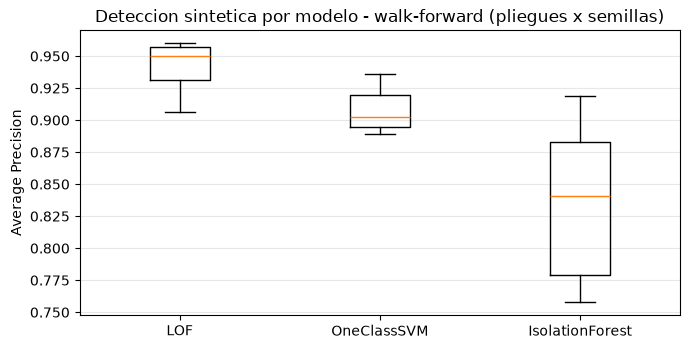

,mean,std,min,max,count
modelo,,,,,
LOF,0.941,0.020,0.906,0.960,12
OneClassSVM,0.908,0.017,0.889,0.936,12
IsolationForest,0.838,0.061,0.758,0.919,12


In [19]:
from sklearn.metrics import average_precision_score


def make_models():
    def wrap(est):
        return Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", RobustScaler()),
            ("model", est),
        ])
    return {
        "IsolationForest": wrap(IsolationForest(n_estimators=400, contamination=0.035, random_state=42, n_jobs=-1)),
        "LOF": wrap(LocalOutlierFactor(n_neighbors=35, contamination=0.035, novelty=True)),
        "OneClassSVM": wrap(OneClassSVM(kernel="rbf", gamma="scale", nu=0.035)),
    }


def inject_archetypes(base, rng, n_per_type=50):
    def take():
        idx = rng.integers(0, len(base), n_per_type)
        return base.iloc[idx].reset_index(drop=True).copy()
    alto = take(); alto["consumo_g_ave_dia_real"] *= 1.9; alto["brecha_consumo_pct_dia"] = alto["brecha_consumo_pct_dia"].abs() + 0.6
    cero = take(); cero["consumo_g_ave_dia_real"] = 0.0; cero["consumo_robust_z_28"] = -6.0
    salto = take(); salto["cambio_consumo_pct_dia"] = 0.9; salto["consumo_robust_z_28"] = 5.0
    mort = take(); mort["mortalidad_por_1000"] = mort["mortalidad_por_1000"] + 40.0
    anomalies = pd.concat([alto, cero, salto, mort], ignore_index=True)
    Xb = pd.concat([base.reset_index(drop=True), anomalies], ignore_index=True)
    yb = np.r_[np.zeros(len(base)), np.ones(len(anomalies))]
    return Xb, yb


# Pliegues rolling-origin (ventana expansiva) por cuantiles de fecha.
ordered_all = features.loc[eligible].sort_values("fecha").reset_index(drop=True)
cut_points = ordered_all["fecha"].quantile([0.5, 0.6, 0.7, 0.8, 0.9]).tolist()
SEEDS_BENCH = [0, 1, 2]

walk_rows = []
for fi in range(len(cut_points) - 1):
    lo, hi = cut_points[fi], cut_points[fi + 1]
    tr = ordered_all[ordered_all["fecha"] <= lo]
    ev = ordered_all[(ordered_all["fecha"] > lo) & (ordered_all["fecha"] <= hi)]
    if len(tr) < 200 or len(ev) < 50:
        continue
    Xtr = tr[MODEL_FEATURES].replace([np.inf, -np.inf], np.nan)
    Xev = ev[MODEL_FEATURES].replace([np.inf, -np.inf], np.nan)
    base = Xev.fillna(Xtr.median())
    models = make_models()
    for m in models.values():
        m.fit(Xtr)
    for seed in SEEDS_BENCH:
        rng = np.random.default_rng(seed)
        Xb, yb = inject_archetypes(base, rng)
        for name, m in models.items():
            ap = average_precision_score(yb, -m.decision_function(Xb))
            walk_rows.append({"fold": fi, "seed": seed, "modelo": name,
                              "ap": round(float(ap), 3), "n_train": len(tr), "n_eval": len(ev)})

walk = pd.DataFrame(walk_rows)
walk_summary = (walk.groupby("modelo")["ap"]
                .agg(["mean", "std", "min", "max", "count"])
                .round(3).sort_values("mean", ascending=False))
print(f"AP en {walk['fold'].nunique()} pliegues temporales x {len(SEEDS_BENCH)} semillas:")
print(walk_summary)

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(7, 3.6))
order = walk_summary.index.tolist()
ax.boxplot([walk.loc[walk["modelo"] == m, "ap"] for m in order])
ax.set_xticklabels(order)
ax.set_ylabel("Average Precision")
ax.set_title("Deteccion sintetica por modelo - walk-forward (pliegues x semillas)")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()
walk_summary

## 18-ter · Modelado por segmento (resuelve la deriva)

Vimos que `edad_semana` y los consumos **derivan fuerte** entre el pasado y el presente — pero eso es en gran parte porque mezclamos **edades/regímenes distintos** en un solo "normal". Aquí probamos **segmentar por banda de edad** y comparamos:

1. **Deriva (PSI medio)** global vs. dentro de cada segmento.
2. **Detección sintética (AP)** de un modelo global vs. **un modelo por segmento**.

**Hipótesis:** dentro de cada banda el "normal" es más estable → **menos deriva** y detección igual o mejor. Si se confirma, el camino correcto a Fase 3 es **un modelo por segmento**, no uno global.

In [20]:
# Segmentación por banda de edad (la feature que más derivó).
seg_base = features.loc[eligible].sort_values("fecha").reset_index(drop=True)
seg_base["_seg"] = (
    pd.cut(seg_base["edad_semana"], bins=[0, 30, 55, 300],
           labels=["16-30 sem", "31-55 sem", "56+ sem"])
    .astype("string").fillna("otros")
)
cut70 = seg_base["fecha"].quantile(0.7)


def mean_psi(tr, ev):
    vals = [population_stability_index(tr[c], ev[c]) for c in MODEL_FEATURES]
    vals = [v for v in vals if np.isfinite(v)]
    return round(float(np.mean(vals)), 2) if vals else np.nan


# (1) Deriva: PSI medio global vs por segmento.
g_tr = seg_base[seg_base["fecha"] <= cut70]
g_ev = seg_base[seg_base["fecha"] > cut70]
psi_rows = [{"segmento": "GLOBAL (sin segmentar)", "psi_medio": mean_psi(g_tr, g_ev),
             "n_train": len(g_tr), "n_eval": len(g_ev)}]
for s, grp in seg_base.groupby("_seg"):
    tr, ev = grp[grp["fecha"] <= cut70], grp[grp["fecha"] > cut70]
    if len(tr) < 50 or len(ev) < 30:
        continue
    psi_rows.append({"segmento": s, "psi_medio": mean_psi(tr, ev),
                     "n_train": len(tr), "n_eval": len(ev)})
psi_segmentos = pd.DataFrame(psi_rows)
print("Deriva (PSI medio de las features) global vs por segmento:")
print(psi_segmentos.to_string(index=False))


# (2) Deteccion sintetica (AP): modelo GLOBAL vs modelos POR SEGMENTO.
def ap_isolation(train_df, eval_df, seed):
    Xtr = train_df[MODEL_FEATURES].replace([np.inf, -np.inf], np.nan)
    Xev = eval_df[MODEL_FEATURES].replace([np.inf, -np.inf], np.nan)
    base = Xev.fillna(Xtr.median())
    model = make_models()["IsolationForest"]
    model.fit(Xtr)
    Xb, yb = inject_archetypes(base, np.random.default_rng(seed))
    return average_precision_score(yb, -model.decision_function(Xb))


ap_global = float(np.mean([ap_isolation(g_tr, g_ev, sd) for sd in [0, 1, 2]]))

num, den = 0.0, 0
for s, grp in seg_base.groupby("_seg"):
    tr, ev = grp[grp["fecha"] <= cut70], grp[grp["fecha"] > cut70]
    if len(tr) < 80 or len(ev) < 40:
        continue
    ap_s = float(np.mean([ap_isolation(tr, ev, sd) for sd in [0, 1, 2]]))
    num += ap_s * len(ev)
    den += len(ev)
ap_segmentado = num / den if den else float("nan")

print(f"\nAP IsolationForest GLOBAL:       {ap_global:.3f}")
print(f"AP IsolationForest POR SEGMENTO: {ap_segmentado:.3f}")
veredicto = "MEJORA" if ap_segmentado > ap_global else "no mejora"
print(f"-> Segmentar por edad {veredicto} la deteccion del Isolation Forest.")
psi_segmentos

Deriva (PSI medio de las features) global vs por segmento:
              segmento  psi_medio  n_train  n_eval
GLOBAL (sin segmentar)       1.14     1347     574
             16-30 sem       0.92      294     294
             31-55 sem       5.19      525      68
               56+ sem       2.32      528     212



AP IsolationForest GLOBAL:       0.692
AP IsolationForest POR SEGMENTO: 0.857
-> Segmentar por edad MEJORA la deteccion del Isolation Forest.


,segmento,psi_medio,n_train,n_eval
0,GLOBAL (sin segmentar),1.14,1347,574
1,16-30 sem,0.92,294,294
2,31-55 sem,5.19,525,68
3,56+ sem,2.32,528,212


## 19 · La decisión: ¿promovemos un modelo?

Cerramos la historia con una **recomendación argumentada** (se completa tras ver estabilidad, sensibilidad, acuerdo y feedback experto; la sección 18 ya imprime una recomendación heurística automática).

Un modelo solo se promueve a producción si:
- **aporta valor por encima de las reglas** (encuentra algo que las reglas no);
- **sus alertas son explicables** para negocio;
- es **estable** en el tiempo y entre semillas;
- mantiene un **volumen de alertas revisable** (ni 0 ni una avalancha);
- **no depende de identificadores** sensibles ni sufre fuga temporal;
- cuenta con **validación experta documentada**.

> Si ningún candidato cumple, la decisión correcta es **mantener el baseline** y volver con mejores features o más datos. **Descartar también es un resultado válido.**